# 🚗 Electric Vehicle Sales in India – Python Project

### Step 1: Import Libraries

In [10]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error


### Step 2: Load and Inspect Dataset

In [11]:

# Load dataset (make sure 'EV_Dataset.csv' is in the same folder)
df = pd.read_csv("EV_Dataset.csv")
print(df.head())
print("\nShape of data:", df.shape)
print("\nData Info:")
print(df.info())


   Year Month_Name      Date           State         Vehicle_Class  \
0  2014        jan  1/1/2014  Andhra Pradesh       ADAPTED VEHICLE   
1  2014        jan  1/1/2014  Andhra Pradesh  AGRICULTURAL TRACTOR   
2  2014        jan  1/1/2014  Andhra Pradesh             AMBULANCE   
3  2014        jan  1/1/2014  Andhra Pradesh   ARTICULATED VEHICLE   
4  2014        jan  1/1/2014  Andhra Pradesh                   BUS   

  Vehicle_Category Vehicle_Type  EV_Sales_Quantity  
0           Others       Others                2.0  
1           Others       Others                6.0  
2           Others       Others                9.0  
3           Others       Others                2.0  
4              Bus          Bus               33.0  

Shape of data: (25729, 8)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25729 entries, 0 to 25728
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year         

### Step 3: Data Cleaning and Preprocessing

In [12]:

df['Year'] = df['Year'].astype(int)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

cat_cols = ['Month_Name', 'State', 'Vehicle_Class', 'Vehicle_Category', 'Vehicle_Type']
for col in cat_cols:
    df[col] = df[col].astype('category')

print("\nMissing values:\n", df.isnull().sum())
df['EV_Sales_Quantity'].fillna(df['EV_Sales_Quantity'].median(), inplace=True)



Missing values:
 Year                 0
Month_Name           0
Date                 0
State                0
Vehicle_Class        0
Vehicle_Category     0
Vehicle_Type         0
EV_Sales_Quantity    1
dtype: int64


/tmp/ipython-input-440628468.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['EV_Sales_Quantity'].fillna(df['EV_Sales_Quantity'].median(), inplace=True)


### Step 4: Exploratory Data Analysis (EDA)

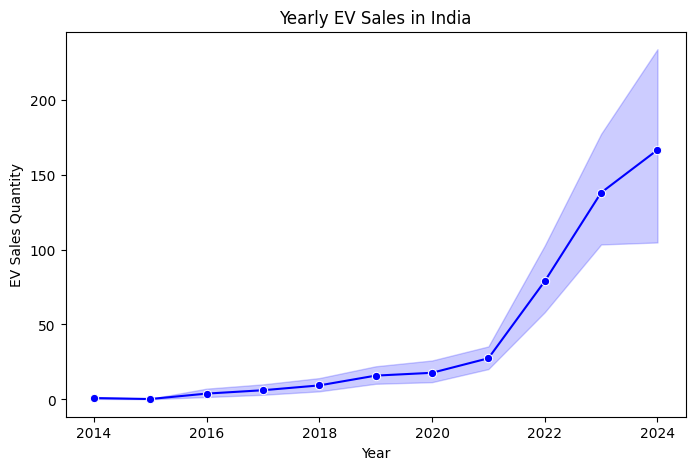

/tmp/ipython-input-3353189709.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Month_Name', y='EV_Sales_Quantity', data=df, ci=None, palette='magma')
/tmp/ipython-input-3353189709.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month_Name', y='EV_Sales_Quantity', data=df, ci=None, palette='magma')


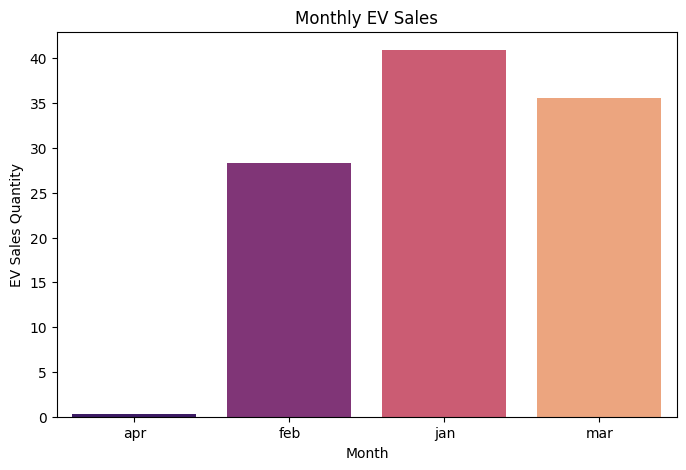

/tmp/ipython-input-3353189709.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  state_sales = df.groupby('State')['EV_Sales_Quantity'].sum().sort_values(ascending=False).head(10)
/tmp/ipython-input-3353189709.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_sales.values, y=state_sales.index, palette='cool')


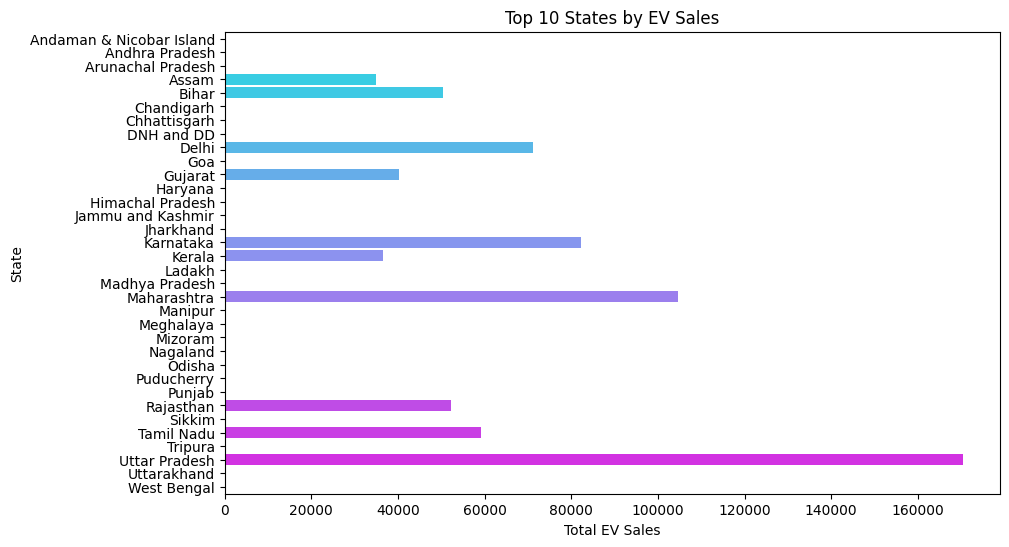

In [13]:

plt.figure(figsize=(8,5))
sns.lineplot(x='Year', y='EV_Sales_Quantity', data=df, marker='o', color='blue')
plt.title("Yearly EV Sales in India")
plt.xlabel("Year")
plt.ylabel("EV Sales Quantity")
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x='Month_Name', y='EV_Sales_Quantity', data=df, ci=None, palette='magma')
plt.title("Monthly EV Sales")
plt.xlabel("Month")
plt.ylabel("EV Sales Quantity")
plt.show()

state_sales = df.groupby('State')['EV_Sales_Quantity'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=state_sales.values, y=state_sales.index, palette='cool')
plt.title("Top 10 States by EV Sales")
plt.xlabel("Total EV Sales")
plt.ylabel("State")
plt.show()


### Step 5: Feature Engineering

In [16]:

df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_encoded.drop(['Date', 'Month_Name'], axis=1, inplace=True)

print("\nEncoded DataFrame shape:", df_encoded.shape)



Encoded DataFrame shape: (25729, 126)


### Step 6: Machine Learning Model

In [20]:
X = df_encoded.drop(['EV_Sales_Quantity'], axis=1)
y = df_encoded['EV_Sales_Quantity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Root Mean Squared Error (RMSE): 88.17


### Step 7: Model Evaluation & Visualization

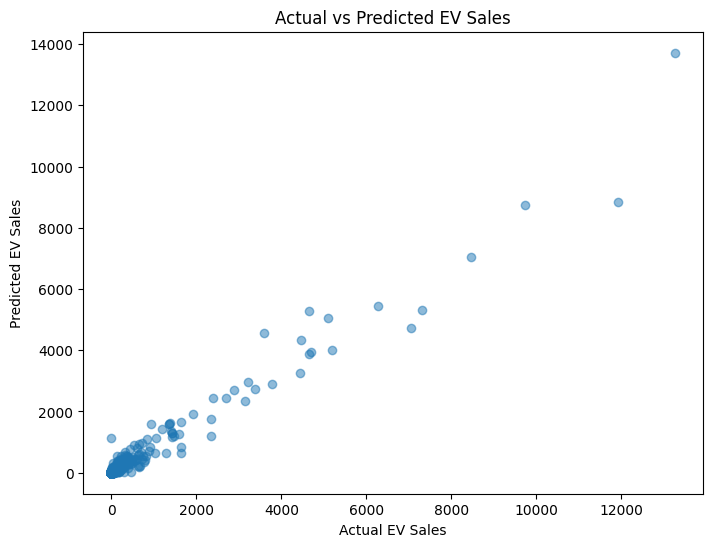

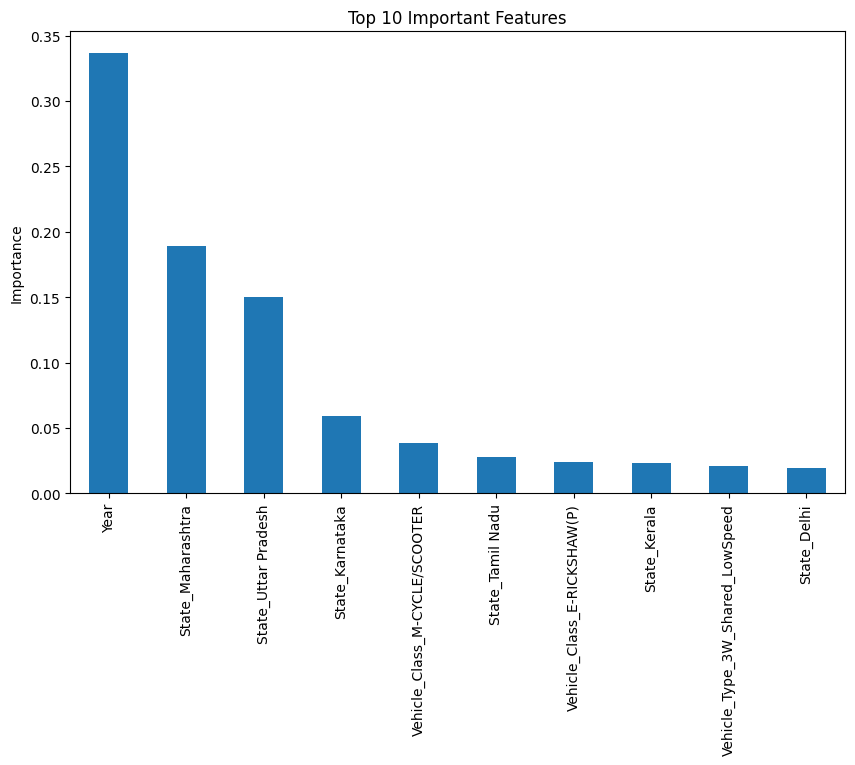

In [21]:

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.title("Actual vs Predicted EV Sales")
plt.xlabel("Actual EV Sales")
plt.ylabel("Predicted EV Sales")
plt.show()

importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.ylabel("Importance")
plt.show()


### Step 8: Conclusion


✅ Cleaned and analyzed EV sales data  
✅ Visualized trends (yearly, monthly, and state-wise)  
✅ Built a Random Forest model to predict sales  
✅ Found key influencing features like state and vehicle type
